# PCOS Detection — Full Ablation Study (FIXED)
## All 5 Models · Single Shared Data Pipeline

| # | Model | Type |
|---|-------|------|
| 1 | EfficientNet-B0 | Standalone baseline |
| 2 | ResNet-50 | Standalone baseline |
| 3 | Dual Fusion (Concat) | Gated concat — learned stream weights, NO L2-norm collapse |
| 4 | Bilinear Fusion | proj_dim=128 to reduce param count, partial backbone unfreeze |
| 5 | Cross-Attention Fusion | Partial backbone unfreeze + view-diverse augmentation |

**Key fixes vs original:**
- **Fix 1** — Fusion models get **view-diverse augmentation**: each backbone sees a differently-augmented version of the same image, forcing complementary (non-redundant) features.
- **Fix 2** — Fusion models **partially unfreeze** the last 2 backbone blocks with a very low LR (lr×0.01), letting the two backbones co-adapt.
- **Fix 3** — `DualFusionModel`: replaced blind L2-norm with a **learned gating scalar** per stream; the model decides per-stream confidence rather than forcing both to equal magnitude.
- **Fix 4** — `BilinearFusionModel`: `proj_dim` reduced to **128** (from 256) to cut the cubic 16.8M→2.1M param bilinear tensor, reducing overfitting.
- **Fix 5** — Fusion models get `EARLY_STOPPING_PATIENCE=15` (vs 10 for baselines) to avoid premature termination during the slower fusion convergence.

**Dataset**: PCOS-XAI Ultrasound — `infected/` and `noninfected/` subfolders

In [1]:
# ============================================================
#  CELL 1 — IMPORTS & DEVICE SETUP
# ============================================================

import os
import sys
import ssl
import re
import time
import hashlib
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

try:
    import imagehash
    IMAGEHASH_AVAILABLE = True
except ImportError:
    IMAGEHASH_AVAILABLE = False
    print("Warning: 'imagehash' not found. Perceptual hashing disabled.")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights, ResNet50_Weights

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
ssl._create_default_https_context = ssl._create_unverified_context

# ── Logging ─────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
log = logging.getLogger(__name__)

# ── Device ──────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps')
    device_label = 'MPS (Apple Silicon)'
elif torch.cuda.is_available():
    device = torch.device('cuda')
    device_label = 'CUDA (NVIDIA GPU)'
else:
    device = torch.device('cpu')
    device_label = 'CPU'

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device_label} ({device})")
log.info(f'Device selected: {device_label} ({device})')

2026-04-03 21:23:38,896 - INFO - Device selected: MPS (Apple Silicon) (mps)


PyTorch  : 2.10.0
Device   : MPS (Apple Silicon) (mps)


In [2]:
# ============================================================
#  CELL 2 — GLOBAL CONFIGURATION
# ============================================================

class Config:
    # ── Dataset ─────────────────────────────────────────────
    DATA_DIR = "/Users/tirtha/final-year-project/PCOS"   # <── CHANGE THIS
    # Expected folder structure:
    #   DATA_DIR/
    #     infected/       (PCOS-positive ultrasound images)
    #     noninfected/    (healthy ovary images)

    # ── Image / Training ────────────────────────────────────
    IMG_SIZE        = (224, 224)
    BATCH_SIZE      = 16
    EPOCHS          = 50
    LEARNING_RATE   = 1e-3
    DROPOUT_RATE    = 0.3

    # ── Data Split ──────────────────────────────────────────
    TRAIN_RATIO = 0.70
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.15

    # ── Classes ─────────────────────────────────────────────
    CLASSES       = ['noninfected', 'infected']
    CLASS_INDICES = {'noninfected': 0, 'infected': 1}
    CLASS_NAMES   = ['Non-infected', 'Infected']

    # ── Deduplication ───────────────────────────────────────
    USE_PERCEPTUAL_HASH  = IMAGEHASH_AVAILABLE
    HASH_SIZE            = 8
    SIMILARITY_THRESHOLD = 5

    # ── Training Controls ───────────────────────────────────
    # FIX 5: Fusion models get more patience (set per-model in Cell 7)
    EARLY_STOPPING_PATIENCE_BASELINE = 10
    EARLY_STOPPING_PATIENCE_FUSION   = 15   # <── more patience for fusion
    OVERFITTING_THRESHOLD   = 0.05
    GRADIENT_CLIP_VALUE     = 1.0

    # ── Fusion Hyperparameters ───────────────────────────────
    # FIX 4: proj_dim reduced from 256→128 to cut bilinear param count
    # (256³=16.8M → 128³=2.1M, much less overfitting)
    PROJ_DIM     = 128

    # Cross-Attention specific
    NUM_HEADS    = 8        # must divide PROJ_DIM evenly
    ATTN_DROPOUT = 0.1

    # ── Output ──────────────────────────────────────────────
    SAVE_DIR = "pcos_ablation_outputs"

config = Config()
os.makedirs(config.SAVE_DIR, exist_ok=True)
print(f"Outputs  : {os.path.abspath(config.SAVE_DIR)}")
log.info(f'Config loaded. Output dir: {os.path.abspath(config.SAVE_DIR)}')

2026-04-03 21:23:38,906 - INFO - Config loaded. Output dir: /Users/tirtha/final year project/3rd/pcos_ablation_outputs


Outputs  : /Users/tirtha/final year project/3rd/pcos_ablation_outputs


In [3]:
# ============================================================
#  CELL 3 — SHARED DATA PIPELINE
#  (used by ALL models — run once)
# ============================================================

# ── 3a: Deduplicator ────────────────────────────────────────

class ImageDeduplicator:
    """Removes exact and near-duplicate images before training."""

    def __init__(self, use_perceptual=True, hash_size=8, similarity_threshold=5):
        self.use_perceptual       = use_perceptual
        self.hash_size            = hash_size
        self.similarity_threshold = similarity_threshold
        self.stats = {'exact_duplicates': 0, 'near_duplicates': 0}

    def _md5(self, path):
        try:
            with open(path, 'rb') as f:
                return hashlib.md5(f.read()).hexdigest()
        except Exception:
            return None

    def _phash(self, path):
        try:
            img = Image.open(path).convert('RGB').resize(
                (self.hash_size * 4, self.hash_size * 4))
            return str(imagehash.phash(img, hash_size=self.hash_size))
        except Exception:
            return None

    def find_duplicates(self, image_paths, labels):
        print("\n=== IMAGE DEDUPLICATION ===")
        print(f"Total images before deduplication: {len(image_paths)}")
        md5_hashes, phashes, unique_indices = {}, {}, []

        for idx, (path, label) in enumerate(zip(image_paths, labels)):
            md5 = self._md5(path)
            if md5 in md5_hashes:
                self.stats['exact_duplicates'] += 1
                continue
            md5_hashes[md5] = path

            if self.use_perceptual:
                ph = self._phash(path)
                if ph:
                    is_near_dup = False
                    for existing_ph in phashes:
                        dist = bin(int(ph, 16) ^ int(existing_ph, 16)).count('1')
                        if dist < self.similarity_threshold:
                            self.stats['near_duplicates'] += 1
                            is_near_dup = True
                            break
                    if not is_near_dup:
                        phashes[ph] = path
                        unique_indices.append(idx)
                else:
                    unique_indices.append(idx)
            else:
                unique_indices.append(idx)

        unique_paths  = [image_paths[i] for i in unique_indices]
        unique_labels = [labels[i] for i in unique_indices]
        print(f"Exact duplicates removed  : {self.stats['exact_duplicates']}")
        print(f"Near-duplicates removed   : {self.stats['near_duplicates']}")
        print(f"Unique images kept        : {len(unique_paths)}")
        return unique_paths, unique_labels


# ── 3b: Patient-aware splitter ──────────────────────────────

class PatientAwareSplitter:
    """Keeps all images from the same patient in the same split."""

    @staticmethod
    def extract_patient_id(path):
        filename = os.path.basename(path)
        match    = re.match(r'([A-Za-z]+[0-9]+)', filename)
        return match.group(1) if match else filename[:8]

    def create_patient_groups(self, image_paths):
        patient_groups = defaultdict(list)
        for idx, path in enumerate(image_paths):
            pid = self.extract_patient_id(path)
            patient_groups[pid].append(idx)
        print(f"\n=== PATIENT GROUPING ===")
        print(f"Unique patients : {len(patient_groups)}")
        print(f"Avg images/pt   : {len(image_paths)/len(patient_groups):.1f}")
        return patient_groups


# ── 3c: Dataset classes ──────────────────────────────────────
#
# FIX 1: We now have TWO dataset classes:
#   - PCOSDataset          : standard (single transform) — for baselines
#   - PCOSDatasetDualView  : returns TWO differently-augmented views of
#                            the same image — for fusion models.
#
# Why dual-view?
#   When both backbones see identical pixels their features are
#   highly correlated — fusion just adds noise. Different augmentations
#   (different crop, flip, colour jitter) force EfficientNet and ResNet
#   to learn complementary features from the same image, giving fusion
#   a real information gain to exploit.

class PCOSDataset(Dataset):
    """Standard PyTorch Dataset — single-view (for baseline models)."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return {
            'image': image,
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
            'path':  self.image_paths[idx],
        }


class PCOSDatasetDualView(Dataset):
    """
    Dual-view Dataset for fusion models (FIX 1).

    Returns two independently-augmented views of every image:
      batch['image_a'] → fed to EfficientNet
      batch['image_b'] → fed to ResNet

    At eval/test time, both views are the same (eval_transform).
    """

    def __init__(self, image_paths, labels,
                 transform_a=None, transform_b=None, eval_transform=None,
                 is_train=False):
        self.image_paths  = image_paths
        self.labels       = labels
        self.transform_a  = transform_a
        self.transform_b  = transform_b
        self.eval_tf      = eval_transform
        self.is_train     = is_train

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.is_train:
            img_a = self.transform_a(image)
            img_b = self.transform_b(image)
        else:
            img_a = self.eval_tf(image)
            img_b = self.eval_tf(image)
        return {
            'image_a': img_a,
            'image_b': img_b,
            'label':   torch.tensor(self.labels[idx], dtype=torch.float32),
            'path':    self.image_paths[idx],
        }


# ── 3d: Load dataset ────────────────────────────────────────

def load_dataset(data_dir, deduplicator):
    """Scans class folders, collects paths and labels, deduplicates."""
    log.info(f'Loading dataset from: {data_dir}')
    image_paths, labels = [], []
    for cls in config.CLASSES:
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.exists(cls_dir):
            log.warning(f'Class dir not found — skipping: {cls_dir}')
            print(f'  Warning: {cls_dir} not found — skipping.')
            continue
        found = sorted([
            os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))
        ])
        log.info(f'  Class "{cls}": {len(found)} images.')
        print(f'  Found {len(found):4d} images in "{cls}"')
        image_paths.extend(found)
        labels.extend([config.CLASS_INDICES[cls]] * len(found))
    if len(image_paths) == 0:
        raise ValueError('No images loaded. Check DATA_DIR and class folder names.')
    return deduplicator.find_duplicates(image_paths, labels)


# ── 3e: Build DataLoaders ────────────────────────────────────

def build_dataloaders(image_paths, labels):
    """Patient-aware stratified split → augmented DataLoaders."""
    log.info('Building patient-aware data splits.')
    splitter       = PatientAwareSplitter()
    patient_groups = splitter.create_patient_groups(image_paths)

    unique_patients, patient_labels = [], []
    for pid, indices in patient_groups.items():
        unique_patients.append(pid)
        pid_labels = [labels[i] for i in indices]
        majority   = max(set(pid_labels), key=lambda lbl: pid_labels.count(lbl))
        patient_labels.append(majority)

    tv_pts, te_pts, tv_lbl, _ = train_test_split(
        unique_patients, patient_labels,
        test_size=config.TEST_RATIO, random_state=42, stratify=patient_labels)

    val_ratio_adj = config.VAL_RATIO / (config.TRAIN_RATIO + config.VAL_RATIO)
    tr_pts, va_pts, _, _ = train_test_split(
        tv_pts, tv_lbl,
        test_size=val_ratio_adj, random_state=42, stratify=tv_lbl)

    def collect(pts):
        idx = []
        for p in pts:
            idx.extend(patient_groups[p])
        return [image_paths[i] for i in idx], [labels[i] for i in idx]

    X_tr, y_tr = collect(tr_pts)
    X_va, y_va = collect(va_pts)
    X_te, y_te = collect(te_pts)

    print(f"\n=== DATA SPLIT ===")
    print(f"  Train : {len(X_tr):4d} images  ({len(tr_pts)} patients)")
    print(f"  Val   : {len(X_va):4d} images  ({len(va_pts)} patients)")
    print(f"  Test  : {len(X_te):4d} images  ({len(te_pts)} patients)")
    print(f"  Batch size : {config.BATCH_SIZE}")
    log.info(f'Split — train:{len(X_tr)}, val:{len(X_va)}, test:{len(X_te)}')

    _mean = [0.485, 0.456, 0.406]
    _std  = [0.229, 0.224, 0.225]

    # ── Standard transform (baselines) ──────────────────────
    train_tf = transforms.Compose([
        transforms.Resize(config.IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2,
                               saturation=0.1, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=_mean, std=_std),
        transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize(config.IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=_mean, std=_std),
    ])

    # FIX 1: Diverse augmentation transforms for fusion models
    # View A (EfficientNet stream): stronger colour jitter + random erasing
    # View B (ResNet stream):       geometric focus (affine, crop) + less colour
    # Both views are different random samples of augmentation, so they diverge.
    fusion_tf_a = transforms.Compose([
        transforms.Resize(config.IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3,   # stronger
                               saturation=0.2, hue=0.15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=_mean, std=_std),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),   # stronger
    ])
    fusion_tf_b = transforms.Compose([
        transforms.Resize(config.IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop(config.IMG_SIZE,
                                      scale=(0.75, 1.0),        # crop variation
                                      ratio=(0.9, 1.1)),
        transforms.RandomRotation(20),                          # wider rotation
        transforms.ColorJitter(brightness=0.1, contrast=0.1,   # milder colour
                               saturation=0.05, hue=0.05),
        transforms.RandomAffine(degrees=0, shear=10),          # shear instead
        transforms.ToTensor(),
        transforms.Normalize(mean=_mean, std=_std),
    ])

    def make_loader_single(paths, lbls, tf, shuffle, drop_last=False):
        ds = PCOSDataset(paths, lbls, tf)
        return DataLoader(ds, batch_size=config.BATCH_SIZE,
                          shuffle=shuffle, num_workers=0,
                          pin_memory=False, drop_last=drop_last)

    def make_loader_dual(paths, lbls, is_train, drop_last=False):
        ds = PCOSDatasetDualView(
            paths, lbls,
            transform_a=fusion_tf_a,
            transform_b=fusion_tf_b,
            eval_transform=eval_tf,
            is_train=is_train,
        )
        return DataLoader(ds, batch_size=config.BATCH_SIZE,
                          shuffle=is_train, num_workers=0,
                          pin_memory=False, drop_last=drop_last)

    # Baseline loaders (single-view)
    train_loader = make_loader_single(X_tr, y_tr, train_tf, True,  drop_last=True)
    val_loader   = make_loader_single(X_va, y_va, eval_tf,  False)
    test_loader  = make_loader_single(X_te, y_te, eval_tf,  False)

    # Fusion loaders (dual-view)
    train_loader_fusion = make_loader_dual(X_tr, y_tr, is_train=True,  drop_last=True)
    val_loader_fusion   = make_loader_dual(X_va, y_va, is_train=False)
    test_loader_fusion  = make_loader_dual(X_te, y_te, is_train=False)

    log.info('DataLoaders ready.')
    return (train_loader, val_loader, test_loader,
            train_loader_fusion, val_loader_fusion, test_loader_fusion)


print("\u2705 Data pipeline classes and functions defined.")

✅ Data pipeline classes and functions defined.


In [4]:
# ============================================================
#  CELL 4 — MODEL DEFINITIONS (all 5 models)
# ============================================================

# ── Helper: partial backbone unfreeze (FIX 2) ───────────────

def unfreeze_last_n_blocks_efficientnet(model_seq, n_blocks=2):
    """
    FIX 2: Unfreeze the last n MBConv blocks of EfficientNet-B0.
    EfficientNet features[0..7] are the 8 MBConv block groups.
    We unfreeze the last n_blocks so the backbone can co-adapt
    during fusion training.
    """
    # features is a Sequential, first element of model_seq
    features = model_seq[0]  # nn.Sequential of blocks
    blocks   = list(features.children())
    # Freeze all first
    for param in model_seq.parameters():
        param.requires_grad = False
    # Unfreeze last n_blocks
    for block in blocks[-n_blocks:]:
        for param in block.parameters():
            param.requires_grad = True


def unfreeze_last_n_layers_resnet(backbone, n_layers=1):
    """
    FIX 2: Unfreeze the last n layer groups of ResNet-50.
    ResNet-50 has layer1..layer4; we unfreeze from the end.
    """
    resnet_stages = ['layer4', 'layer3', 'layer2', 'layer1']
    # Freeze all first
    for param in backbone.parameters():
        param.requires_grad = False
    # Unfreeze last n stages
    for stage_name in resnet_stages[:n_layers]:
        for param in getattr(backbone, stage_name).parameters():
            param.requires_grad = True


# ── Model 1: EfficientNet-B0 (standalone baseline) ──────────

class EfficientNetB0Model(nn.Module):
    """
    Standalone EfficientNet-B0 baseline.
    1280-dim penultimate features → classifier head.
    Unchanged from original.
    """
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        eff = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.features = nn.Sequential(eff.features, eff.avgpool, nn.Flatten())
        for param in list(self.features.parameters())[:-30]:
            param.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(1280, 256),
            nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(128, 1), nn.Sigmoid(),
        )
        tp = sum(p.numel() for p in self.parameters() if p.requires_grad)
        log.info(f'EfficientNet-B0 — trainable params: {tp:,}')
        print(f'  EfficientNet-B0         trainable params: {tp:,}')

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Model 2: ResNet-50 (standalone baseline) ─────────────────

class ResNet50Model(nn.Module):
    """
    Standalone ResNet-50 baseline.
    2048-dim penultimate features → classifier head.
    Unchanged from original.
    """
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        res    = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        res.fc = nn.Identity()
        self.backbone = res
        for param in list(self.backbone.parameters())[:-30]:
            param.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(2048, 256),
            nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(128, 1), nn.Sigmoid(),
        )
        tp = sum(p.numel() for p in self.parameters() if p.requires_grad)
        log.info(f'ResNet-50 — trainable params: {tp:,}')
        print(f'  ResNet-50               trainable params: {tp:,}')

    def forward(self, x):
        return self.classifier(self.backbone(x))


# ── Model 3: Dual Fusion (Gated Concatenation) ───────────────

class DualFusionModel(nn.Module):
    """
    Gated Concatenation Fusion.

    Changes vs original:
    - FIX 2: Last 2 EfficientNet blocks + ResNet layer4 are unfrozen
             (with lr*0.01 in optimizer) so backbones co-adapt.
    - FIX 3: Replaced hard L2-normalisation with a learned gating
             scalar (alpha, beta) per stream. Instead of forcing both
             branches onto the unit hypersphere (losing magnitude =
             losing confidence), the model learns to weight each stream.
             Gate is sigmoid-bounded [0,1] and initialised to 0.5.
    - FIX 1: forward() accepts (image_a, image_b) separately so each
             backbone sees a different augmented view at train time.
    """
    def __init__(self, dropout_rate=0.3):
        super().__init__()

        eff = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.eff_features = nn.Sequential(eff.features, eff.avgpool, nn.Flatten())

        res    = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        res.fc = nn.Identity()
        self.res_backbone = res

        # FIX 2: Partial unfreeze — last 2 EfficientNet blocks + ResNet layer4
        unfreeze_last_n_blocks_efficientnet(self.eff_features, n_blocks=2)
        unfreeze_last_n_layers_resnet(self.res_backbone, n_layers=1)

        self.eff_proj = nn.Sequential(
            nn.Linear(1280, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True)
        )
        self.res_proj = nn.Sequential(
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True)
        )

        # FIX 3: Learned gate scalars — replaces blind L2-norm
        # gate_eff and gate_res are scalar logits → sigmoid gives weight in (0,1)
        # Initialised to 0 → sigmoid(0) = 0.5 (equal weighting at start)
        self.gate_eff = nn.Parameter(torch.zeros(1))
        self.gate_res = nn.Parameter(torch.zeros(1))

        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(128, 1), nn.Sigmoid(),
        )
        tp = sum(p.numel() for p in self.parameters() if p.requires_grad)
        log.info(f'DualFusionModel (Gated) — trainable params: {tp:,}')
        print(f'  Dual Fusion (Concat)    trainable params: {tp:,}')

    def forward(self, x_a, x_b):
        """x_a → EfficientNet stream, x_b → ResNet stream."""
        f_eff = self.eff_features(x_a)          # (B, 1280)
        f_res = self.res_backbone(x_b)          # (B, 2048)
        p_eff = self.eff_proj(f_eff)            # (B, 512)
        p_res = self.res_proj(f_res)            # (B, 512)
        # FIX 3: scale each stream by its learned gate instead of L2-norm
        g_eff = torch.sigmoid(self.gate_eff)    # scalar in (0,1)
        g_res = torch.sigmoid(self.gate_res)    # scalar in (0,1)
        fused = torch.cat([g_eff * p_eff, g_res * p_res], dim=1)  # (B,1024)
        return self.classifier(fused)


# ── Model 4: Bilinear Fusion ──────────────────────────────────

class BilinearFusionModel(nn.Module):
    """
    Bilinear Pooling Fusion.

    Changes vs original:
    - FIX 2: Partial backbone unfreeze (same as DualFusion above).
    - FIX 4: proj_dim default reduced to 128 (from 256).
             Bilinear weight tensor: 256³=16.8M → 128³=2.1M params.
             This dramatically reduces overfitting risk.
    - FIX 1: forward() accepts (x_a, x_b) for dual-view.
    """
    def __init__(self, dropout_rate=0.3, proj_dim=128):
        super().__init__()
        self.proj_dim = proj_dim

        eff = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.eff_features = nn.Sequential(eff.features, eff.avgpool, nn.Flatten())

        res    = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        res.fc = nn.Identity()
        self.res_backbone = res

        # FIX 2: Partial unfreeze
        unfreeze_last_n_blocks_efficientnet(self.eff_features, n_blocks=2)
        unfreeze_last_n_layers_resnet(self.res_backbone, n_layers=1)

        self.proj_eff = nn.Linear(1280, proj_dim)
        self.proj_res = nn.Linear(2048, proj_dim)
        self.bilinear = nn.Bilinear(proj_dim, proj_dim, proj_dim)

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(proj_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )
        tp = sum(p.numel() for p in self.parameters() if p.requires_grad)
        log.info(f'BilinearFusionModel — trainable params: {tp:,}')
        print(f'  Bilinear Fusion         trainable params: {tp:,}')
        print(f'    proj_dim={proj_dim} | bilinear tensor: '
              f'{proj_dim}\u00b3 = {proj_dim**3:,} params')

    def forward(self, x_a, x_b):
        f_eff = self.eff_features(x_a)             # (B, 1280)
        f_res = self.res_backbone(x_b)             # (B, 2048)
        p_eff = torch.relu(self.proj_eff(f_eff))   # (B, proj_dim)
        p_res = torch.relu(self.proj_res(f_res))   # (B, proj_dim)
        fused = self.bilinear(p_eff, p_res)        # (B, proj_dim)
        return self.classifier(fused)


# ── Model 5: Cross-Attention Fusion ──────────────────────────

class CrossAttentionFusionModel(nn.Module):
    """
    Cross-Attention Fusion.

    Changes vs original:
    - FIX 2: Partial backbone unfreeze.
    - FIX 1: forward() accepts (x_a, x_b) for dual-view.
    Everything else (attention architecture, FFN, residuals) unchanged.
    """

    def __init__(self, dropout_rate=0.3, proj_dim=128,
                 num_heads=8, attn_dropout=0.1):
        super().__init__()
        assert proj_dim % num_heads == 0, (
            f"proj_dim ({proj_dim}) must be divisible by num_heads ({num_heads})")

        self.proj_dim  = proj_dim
        self.num_heads = num_heads

        eff = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.eff_features = nn.Sequential(eff.features, eff.avgpool, nn.Flatten())

        res    = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        res.fc = nn.Identity()
        self.res_backbone = res

        # FIX 2: Partial unfreeze
        unfreeze_last_n_blocks_efficientnet(self.eff_features, n_blocks=2)
        unfreeze_last_n_layers_resnet(self.res_backbone, n_layers=1)

        self.proj_eff      = nn.Linear(1280, proj_dim)
        self.proj_res      = nn.Linear(2048, proj_dim)
        self.norm_proj_eff = nn.LayerNorm(proj_dim)
        self.norm_proj_res = nn.LayerNorm(proj_dim)

        self.cross_attn_eff2res = nn.MultiheadAttention(
            embed_dim=proj_dim, num_heads=num_heads,
            dropout=attn_dropout, batch_first=True)
        self.norm_eff_post_attn = nn.LayerNorm(proj_dim)
        self.ffn_eff = nn.Sequential(
            nn.Linear(proj_dim, proj_dim * 4), nn.GELU(),
            nn.Dropout(attn_dropout),
            nn.Linear(proj_dim * 4, proj_dim),
        )
        self.norm_eff_post_ffn = nn.LayerNorm(proj_dim)

        self.cross_attn_res2eff = nn.MultiheadAttention(
            embed_dim=proj_dim, num_heads=num_heads,
            dropout=attn_dropout, batch_first=True)
        self.norm_res_post_attn = nn.LayerNorm(proj_dim)
        self.ffn_res = nn.Sequential(
            nn.Linear(proj_dim, proj_dim * 4), nn.GELU(),
            nn.Dropout(attn_dropout),
            nn.Linear(proj_dim * 4, proj_dim),
        )
        self.norm_res_post_ffn = nn.LayerNorm(proj_dim)

        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(proj_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

        tp = sum(p.numel() for p in self.parameters() if p.requires_grad)
        log.info(f'CrossAttentionFusionModel — trainable params: {tp:,}')
        print(f'  Cross-Attention Fusion  trainable params: {tp:,}')
        print(f'    proj_dim={proj_dim} | num_heads={num_heads} | attn_dropout={attn_dropout}')

    def _cross_attn_block(self, query_vec, kv_vec,
                          attn_module, norm_attn, ffn, norm_ffn):
        q = query_vec.unsqueeze(1)
        k = kv_vec.unsqueeze(1)
        attn_out, attn_weights = attn_module(
            query=q, key=k, value=k,
            need_weights=True, average_attn_weights=True)
        x = norm_attn(q + attn_out)
        x = norm_ffn(x + ffn(x))
        return x.squeeze(1), attn_weights

    def forward(self, x_a, x_b, return_attention=False):
        """x_a → EfficientNet, x_b → ResNet."""
        f_eff = self.eff_features(x_a)
        f_res = self.res_backbone(x_b)

        e = self.norm_proj_eff(self.proj_eff(f_eff))
        r = self.norm_proj_res(self.proj_res(f_res))

        e_ctx, w_eff2res = self._cross_attn_block(
            e, r,
            self.cross_attn_eff2res, self.norm_eff_post_attn,
            self.ffn_eff, self.norm_eff_post_ffn)

        r_ctx, w_res2eff = self._cross_attn_block(
            r, e,
            self.cross_attn_res2eff, self.norm_res_post_attn,
            self.ffn_res, self.norm_res_post_ffn)

        fused  = torch.cat([e_ctx, r_ctx], dim=1)
        output = self.classifier(fused)

        if return_attention:
            return output, w_eff2res, w_res2eff
        return output


print("\u2705 All 5 model classes defined (with fixes).")

✅ All 5 model classes defined (with fixes).


In [5]:
# ============================================================
#  CELL 5 — TRAINING ENGINE
# ============================================================

LOG_EVERY_N_BATCHES = 20


def build_optimizer(model, lr, is_fusion=False):
    """
    Differential learning rates:
      backbone layers (frozen)      → skipped
      backbone layers (unfrozen)    → lr × 0.01  (very slow — preserve pretrained)
      heads / fusion / proj layers  → lr          (train from scratch)

    FIX 2: For fusion models, partially-unfrozen backbone params get lr*0.01
    instead of lr*0.1, because they were fully frozen pretrained weights and
    need an even smaller nudge to co-adapt without catastrophic forgetting.
    """
    HEAD_KEYWORDS = (
        'classifier', 'eff_proj', 'res_proj', 'proj_eff', 'proj_res',
        'bilinear', 'norm_proj', 'cross_attn', 'norm_eff', 'norm_res',
        'ffn_eff', 'ffn_res', 'gate_eff', 'gate_res',
    )
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(k in name for k in HEAD_KEYWORDS):
            head_params.append(param)
        else:
            backbone_params.append(param)

    backbone_lr = lr * 0.01 if is_fusion else lr * 0.1
    return optim.AdamW([
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params,     'lr': lr},
    ], weight_decay=1e-4)


def train_one_epoch_single(model, loader, optimizer, criterion, epoch_num=0):
    """Training loop for baseline (single-view) models."""
    model.train()
    total_loss = correct = total = 0
    for batch_idx, batch in enumerate(loader):
        imgs = batch['image'].to(device)
        lbls = batch['label'].to(device).unsqueeze(1)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP_VALUE)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += ((out > 0.5).float() == lbls).sum().item()
        total      += lbls.size(0)
        if batch_idx % LOG_EVERY_N_BATCHES == 0:
            log.debug(f'  [Epoch {epoch_num} Batch {batch_idx}/{len(loader)}] loss={loss.item():.4f}')
    return total_loss / total, correct / total


def train_one_epoch_dual(model, loader, optimizer, criterion, epoch_num=0):
    """
    Training loop for fusion (dual-view) models.
    Passes image_a to EfficientNet stream and image_b to ResNet stream.
    """
    model.train()
    total_loss = correct = total = 0
    for batch_idx, batch in enumerate(loader):
        imgs_a = batch['image_a'].to(device)
        imgs_b = batch['image_b'].to(device)
        lbls   = batch['label'].to(device).unsqueeze(1)
        optimizer.zero_grad()
        out  = model(imgs_a, imgs_b)
        loss = criterion(out, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP_VALUE)
        optimizer.step()
        total_loss += loss.item() * imgs_a.size(0)
        correct    += ((out > 0.5).float() == lbls).sum().item()
        total      += lbls.size(0)
        if batch_idx % LOG_EVERY_N_BATCHES == 0:
            log.debug(f'  [Epoch {epoch_num} Batch {batch_idx}/{len(loader)}] loss={loss.item():.4f}')
    return total_loss / total, correct / total


def evaluate_loader_single(model, loader, criterion):
    """Evaluation for baseline models."""
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for batch in loader:
            imgs = batch['image'].to(device)
            lbls = batch['label'].to(device).unsqueeze(1)
            out  = model(imgs)
            total_loss += criterion(out, lbls).item() * imgs.size(0)
            correct    += ((out > 0.5).float() == lbls).sum().item()
            total      += lbls.size(0)
    return total_loss / total, correct / total


def evaluate_loader_dual(model, loader, criterion):
    """Evaluation for fusion models."""
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for batch in loader:
            imgs_a = batch['image_a'].to(device)
            imgs_b = batch['image_b'].to(device)
            lbls   = batch['label'].to(device).unsqueeze(1)
            out    = model(imgs_a, imgs_b)
            total_loss += criterion(out, lbls).item() * imgs_a.size(0)
            correct    += ((out > 0.5).float() == lbls).sum().item()
            total      += lbls.size(0)
    return total_loss / total, correct / total


def run_inference_single(model, loader):
    """Inference for baseline models."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            probs = model(imgs).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(batch['label'].numpy())
    return np.array(all_labels), np.array(all_probs)


def run_inference_dual(model, loader, return_attn=False):
    """Inference for fusion models (dual-view)."""
    model.eval()
    all_probs, all_labels = [], []
    all_w_e2r, all_w_r2e = [], []
    with torch.no_grad():
        for batch in loader:
            imgs_a = batch['image_a'].to(device)
            imgs_b = batch['image_b'].to(device)
            if return_attn:
                out, w_e2r, w_r2e = model(imgs_a, imgs_b, return_attention=True)
                all_w_e2r.extend(w_e2r.cpu().numpy().reshape(-1))
                all_w_r2e.extend(w_r2e.cpu().numpy().reshape(-1))
            else:
                out = model(imgs_a, imgs_b)
            all_probs.extend(out.cpu().numpy().flatten())
            all_labels.extend(batch['label'].numpy())
    if return_attn:
        return (np.array(all_labels), np.array(all_probs),
                np.array(all_w_e2r), np.array(all_w_r2e))
    return np.array(all_labels), np.array(all_probs)


def train_model(name, model, train_loader, val_loader,
                num_epochs, lr, patience, save_dir, is_fusion=False):
    """
    Full training loop with early stopping, LR scheduling,
    best-checkpoint saving, and overfitting detection.

    is_fusion: if True, uses dual-view loaders and build_optimizer with
               backbone_lr=lr*0.01.
    """
    log.info(f'Starting training for: {name}')
    criterion = nn.BCELoss()
    optimizer = build_optimizer(model, lr, is_fusion=is_fusion)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5)

    train_epoch_fn = train_one_epoch_dual   if is_fusion else train_one_epoch_single
    eval_fn        = evaluate_loader_dual   if is_fusion else evaluate_loader_single

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'overfit_epochs': []
    }
    best_val_acc = 0.0
    no_improve   = 0
    best_state   = None
    save_path    = os.path.join(
        save_dir,
        f"best_{name.lower().replace(' ','_').replace('-','')}.pth"
    )

    print(f"\n{'='*65}")
    print(f"  Training: {name}  [{'fusion+dual-view' if is_fusion else 'baseline'}]")
    print(f"{'='*65}")
    sys.stdout.flush()

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch_fn(
            model, train_loader, optimizer, criterion, epoch_num=epoch)
        va_loss, va_acc = eval_fn(model, val_loader, criterion)
        scheduler.step(va_loss)

        current_lr = optimizer.param_groups[-1]['lr']
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        overfit_flag = ''
        if epoch > 5 and (tr_acc - va_acc) > config.OVERFITTING_THRESHOLD:
            history['overfit_epochs'].append(epoch)
            overfit_flag = '  [overfit]'

        saved = ''
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
            saved        = '  *** best ***'
            torch.save({
                'model_state_dict': best_state,
                'val_acc':   best_val_acc,
                'epoch':     epoch,
                'proj_dim':  getattr(model, 'proj_dim', None),
                'num_heads': getattr(model, 'num_heads', None),
            }, save_path)
        else:
            no_improve += 1

        elapsed = time.time() - t0
        print(f"  Epoch {epoch:3d}/{num_epochs} | "
              f"Tr {tr_loss:.4f}/{tr_acc:.4f}  "
              f"Va {va_loss:.4f}/{va_acc:.4f}  "
              f"LR {current_lr:.1e}  "
              f"{elapsed:.0f}s{saved}{overfit_flag}")
        sys.stdout.flush()

        if no_improve >= patience:
            print(f'\n  Early stopping at epoch {epoch}.')
            break

    if best_state:
        model.load_state_dict(best_state)
    print(f'\n  Best validation accuracy : {best_val_acc:.4f}')
    print(f'  Checkpoint saved         : {save_path}')
    return history, save_path


print("\u2705 Training engine functions defined.")

✅ Training engine functions defined.


In [6]:
# ============================================================
#  CELL 6 — EVALUATION, REPORTING & VISUALISATION
#  (unchanged from original)
# ============================================================

PALETTE = {
    'EfficientNet-B0':        '#534AB7',
    'ResNet-50':              '#0F6E56',
    'Dual Fusion (Concat)':   '#E67E22',
    'Bilinear Fusion':        '#2980B9',
    'Cross-Attention Fusion': '#C0392B',
}
LINESTYLE = {
    'EfficientNet-B0':        '-',
    'ResNet-50':              '--',
    'Dual Fusion (Concat)':   '-.',
    'Bilinear Fusion':        ':',
    'Cross-Attention Fusion': (0, (5, 1)),
}


def print_classification_report(name, labels, preds):
    log.info(f'Classification report for: {name}')
    print(f"\n{'='*65}")
    print(f"  Classification Report: {name}")
    print(f"{'='*65}")
    print(classification_report(
        labels, preds,
        target_names=config.CLASS_NAMES, digits=2))


def collect_all_metrics(results_list):
    rows = []
    for r in results_list:
        l, pr, pd_ = r['labels'], r['probs'], r['preds']
        row = {
            'Model':     r['name'],
            'Accuracy':  round(accuracy_score(l, pd_), 4),
            'Precision': round(precision_score(l, pd_, zero_division=0), 4),
            'Recall':    round(recall_score(l, pd_, zero_division=0), 4),
            'F1-Score':  round(f1_score(l, pd_, zero_division=0), 4),
            'AUC-ROC':   round(roc_auc_score(l, pr), 4),
        }
        rows.append(row)
    return pd.DataFrame(rows).set_index('Model')


def print_summary_table(df_summary):
    print("\n" + "=" * 65)
    print("  ABLATION STUDY — SUMMARY TABLE")
    print("  All 5 Models · Shared Data Pipeline")
    print("=" * 65)
    print(df_summary.to_string())
    print("\n  Best model per metric:")
    for col in df_summary.columns:
        winner = df_summary[col].idxmax()
        print(f"    {col:12s}: {winner}  ({df_summary.loc[winner, col]:.4f})")


def _plot_single_cm(ax, labels, preds, title, class_names):
    cm    = confusion_matrix(labels, preds)
    im    = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('Predicted label', fontsize=8)
    ax.set_ylabel('True label', fontsize=8)
    ticks = range(len(class_names))
    ax.set_xticks(ticks)
    ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=7)
    ax.set_yticks(ticks)
    ax.set_yticklabels(class_names, fontsize=7)
    thresh = cm.max() / 2.0
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if cm[r, c] > thresh else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def plot_evaluation_figure(results_list, save_dir):
    log.info('Plotting evaluation figure.')
    n   = len(results_list)
    fig = plt.figure(figsize=(5 * n, 14))
    fig.suptitle(
        'PCOS Ablation Study — All 5 Models (Fixed)\n'
        'EfficientNet-B0 | ResNet-50 | Dual Fusion | Bilinear | Cross-Attention\n'
        'PCOS-XAI Ultrasound Dataset',
        fontsize=11, fontweight='bold', y=1.01)

    for i, res in enumerate(results_list):
        ax = fig.add_subplot(3, n, i + 1)
        _plot_single_cm(ax, res['labels'], res['preds'],
                        f"CM: {res['name']}", config.CLASS_NAMES)

    for i, res in enumerate(results_list):
        ax          = fig.add_subplot(3, n, n + i + 1)
        fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
        roc_val     = auc(fpr, tpr)
        color       = PALETTE[res['name']]
        ax.plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {roc_val:.4f}')
        ax.fill_between(fpr, tpr, alpha=0.10, color=color)
        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
        ax.set_title(f"ROC — {res['name']}", fontsize=9, fontweight='bold', pad=6)
        ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)

    ax_comb = fig.add_subplot(3, 1, 3)
    for res in results_list:
        fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
        roc_val     = auc(fpr, tpr)
        ax_comb.plot(fpr, tpr,
                     color=PALETTE[res['name']],
                     lw=2.5,
                     linestyle=LINESTYLE[res['name']],
                     label=f"{res['name']}  (AUC = {roc_val:.4f})")
    ax_comb.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random')
    ax_comb.set_xlim([0.0, 1.0]); ax_comb.set_ylim([0.0, 1.05])
    ax_comb.set_xlabel('False Positive Rate', fontsize=11)
    ax_comb.set_ylabel('True Positive Rate', fontsize=11)
    ax_comb.set_title('ROC Curve Comparison — All 5 Models',
                      fontsize=12, fontweight='bold')
    ax_comb.legend(loc='lower right', fontsize=9); ax_comb.grid(alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(save_dir, 'ablation_evaluation.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved \u2192 {out_path}')


def plot_training_curves(all_histories, save_dir):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Training History — All 5 Models\n(dashed = train, solid = validation)',
                 fontsize=12, fontweight='bold')
    for name, hist in all_histories.items():
        ep    = range(1, len(hist['train_loss']) + 1)
        color = PALETTE[name]
        ax1.plot(ep, hist['train_loss'], color=color, lw=1.2, linestyle='--', alpha=0.6)
        ax1.plot(ep, hist['val_loss'],   color=color, lw=2, label=name)
        ax2.plot(ep, hist['train_acc'],  color=color, lw=1.2, linestyle='--', alpha=0.6)
        ax2.plot(ep, hist['val_acc'],    color=color, lw=2, label=name)
    for ax, title, ylabel in [(ax1, 'BCE Loss', 'Loss'), (ax2, 'Accuracy', 'Accuracy')]:
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    out_path = os.path.join(save_dir, 'ablation_training_curves.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved \u2192 {out_path}')


def plot_metric_bar_chart(df_summary, save_dir):
    metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    n_models = len(df_summary)
    x     = np.arange(len(metric_keys))
    width = 0.15
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle('Metric Comparison — All 5 Models (Fixed)', fontsize=12, fontweight='bold')
    for i, (model_name, row) in enumerate(df_summary.iterrows()):
        vals = [row[m] for m in metric_keys]
        bars = ax.bar(x + i * width, vals, width,
                      label=model_name, color=PALETTE[model_name], alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=6.5)
    ax.set_xticks(x + width * (n_models - 1) / 2)
    ax.set_xticklabels(metric_keys, fontsize=10)
    ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    out_path = os.path.join(save_dir, 'ablation_metrics_bar.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved \u2192 {out_path}')


def visualise_attention_weights(model, test_loader, save_dir):
    log.info('Extracting cross-attention weights.')
    model.eval()
    labels_arr, probs_arr, w_e2r_arr, w_r2e_arr = run_inference_dual(
        model, test_loader, return_attn=True)

    preds_arr = (probs_arr >= 0.5).astype(int)
    records = []
    for prob, lbl, a1, a2 in zip(probs_arr, labels_arr, w_e2r_arr, w_r2e_arr):
        records.append({
            'prob':         prob,
            'label':        int(lbl),
            'class_name':   config.CLASS_NAMES[int(lbl)],
            'attn_eff2res': float(a1),
            'attn_res2eff': float(a2),
            'predicted':    int(prob >= 0.5),
            'correct':      int((prob >= 0.5) == lbl),
        })

    df_attn  = pd.DataFrame(records)
    csv_path = os.path.join(save_dir, 'crossattn_attention_weights.csv')
    df_attn.to_csv(csv_path, index=False)
    print(f'Attention weights saved \u2192 {csv_path}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Cross-Attention Weight Analysis', fontsize=12, fontweight='bold')
    colors_cls = {0: '#0F6E56', 1: '#C0392B'}

    ax = axes[0]
    for lbl, grp in df_attn.groupby('label'):
        ax.scatter(grp['attn_eff2res'], grp['prob'],
                   c=colors_cls[lbl], alpha=0.5, s=20, label=config.CLASS_NAMES[lbl])
    ax.set_xlabel('Eff\u2192Res attention', fontsize=9)
    ax.set_ylabel('Predicted PCOS probability', fontsize=9)
    ax.set_title('Eff\u2192Res attention vs prediction', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1]
    bp1 = ax.boxplot(
        [df_attn[df_attn['label'] == 0]['attn_eff2res'].values,
         df_attn[df_attn['label'] == 1]['attn_eff2res'].values],
        positions=[1, 2], widths=0.6, patch_artist=True,
        boxprops=dict(facecolor='#534AB7', alpha=0.6))
    bp2 = ax.boxplot(
        [df_attn[df_attn['label'] == 0]['attn_res2eff'].values,
         df_attn[df_attn['label'] == 1]['attn_res2eff'].values],
        positions=[4, 5], widths=0.6, patch_artist=True,
        boxprops=dict(facecolor='#C0392B', alpha=0.6))
    ax.set_xticks([1, 2, 4, 5])
    ax.set_xticklabels(['Non-inf\n(E\u2192R)', 'PCOS\n(E\u2192R)',
                        'Non-inf\n(R\u2192E)', 'PCOS\n(R\u2192E)'], fontsize=8)
    ax.set_ylabel('Attention weight', fontsize=9)
    ax.set_title('Attention distribution per class', fontsize=10, fontweight='bold')
    ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Eff\u2192Res', 'Res\u2192Eff'], fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    ax = axes[2]
    for lbl, grp in df_attn.groupby('label'):
        ax.scatter(grp['attn_eff2res'], grp['attn_res2eff'],
                   c=colors_cls[lbl], alpha=0.5, s=20, label=config.CLASS_NAMES[lbl])
    corr = df_attn['attn_eff2res'].corr(df_attn['attn_res2eff'])
    ax.text(0.05, 0.92, f'Pearson r = {corr:.3f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))
    ax.set_xlabel('Eff\u2192Res attention', fontsize=9)
    ax.set_ylabel('Res\u2192Eff attention', fontsize=9)
    ax.set_title('Bidirectional attention correlation', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(save_dir, 'crossattn_attention_analysis.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved \u2192 {out_path}')
    return df_attn


print("\u2705 Evaluation, reporting and visualisation functions defined.")

✅ Evaluation, reporting and visualisation functions defined.


2026-04-03 21:23:39,048 - INFO - === PCOS ABLATION STUDY (FIXED) — STARTING ===
2026-04-03 21:23:39,050 - INFO - Loading dataset from: /Users/tirtha/final-year-project/PCOS
2026-04-03 21:23:39,066 - INFO -   Class "noninfected": 5000 images.
2026-04-03 21:23:39,087 - INFO -   Class "infected": 6784 images.


  PCOS ABLATION STUDY — ALL 5 MODELS (FIXED)
  Device     : MPS (Apple Silicon) (mps)
  Data dir   : /Users/tirtha/final-year-project/PCOS
  Epochs     : 50  |  Batch: 16  |  LR: 0.001

[STEP 1] Loading and deduplicating dataset...
  Found 5000 images in "noninfected"
  Found 6784 images in "infected"

=== IMAGE DEDUPLICATION ===
Total images before deduplication: 11784


2026-04-03 21:23:44,842 - INFO - Building patient-aware data splits.
2026-04-03 21:23:44,848 - INFO - Split — train:2025, val:295, test:296
2026-04-03 21:23:44,848 - INFO - DataLoaders ready.
2026-04-03 21:23:44,918 - INFO - EfficientNet-B0 — trainable params: 2,079,265


Exact duplicates removed  : 7788
Near-duplicates removed   : 1380
Unique images kept        : 2616

[STEP 2] Building patient-aware DataLoaders...

=== PATIENT GROUPING ===
Unique patients : 1172
Avg images/pt   : 2.2

=== DATA SPLIT ===
  Train : 2025 images  (820 patients)
  Val   :  295 images  (176 patients)
  Test  :  296 images  (176 patients)
  Batch size : 16
  Baseline  train/val/test batches : 126 / 19 / 19
  Fusion    train/val/test batches : 126 / 19 / 19

[STEP 3] Initialising all 5 models...
  EfficientNet-B0         trainable params: 2,079,265


2026-04-03 21:23:45,339 - INFO - ResNet-50 — trainable params: 15,523,073


...


  Classification Report: Dual Fusion (Concat)
              precision    recall  f1-score   support

Non-infected       0.94      1.00      0.97        67
    Infected       1.00      0.98      0.99       229

    accuracy                           0.99       296
   macro avg       0.97      0.99      0.98       296
weighted avg       0.99      0.99      0.99       296



2026-04-03 23:01:46,019 - INFO - Classification report for: Bilinear Fusion



  Classification Report: Bilinear Fusion
              precision    recall  f1-score   support

Non-infected       0.93      1.00      0.96        67
    Infected       1.00      0.98      0.99       229

    accuracy                           0.98       296
   macro avg       0.97      0.99      0.98       296
weighted avg       0.98      0.98      0.98       296



2026-04-03 23:01:50,644 - INFO - Classification report for: Cross-Attention Fusion
2026-04-03 23:01:50,720 - INFO - Extracting cross-attention weights.



  Classification Report: Cross-Attention Fusion
              precision    recall  f1-score   support

Non-infected       0.96      1.00      0.98        67
    Infected       1.00      0.99      0.99       229

    accuracy                           0.99       296
   macro avg       0.98      0.99      0.99       296
weighted avg       0.99      0.99      0.99       296


  ABLATION STUDY — SUMMARY TABLE
  All 5 Models · Shared Data Pipeline
                        Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                                 
EfficientNet-B0           0.9899     0.9956  0.9913    0.9934   0.9959
ResNet-50                 0.9899     0.9913  0.9956    0.9935   0.9964
Dual Fusion (Concat)      0.9865     1.0000  0.9825    0.9912   0.9975
Bilinear Fusion           0.9831     1.0000  0.9782    0.9890   0.9974
Cross-Attention Fusion    0.9899     1.0000  0.9869    0.9934   0.9977

  Best model per metric:
    Accuracy    : EfficientNe

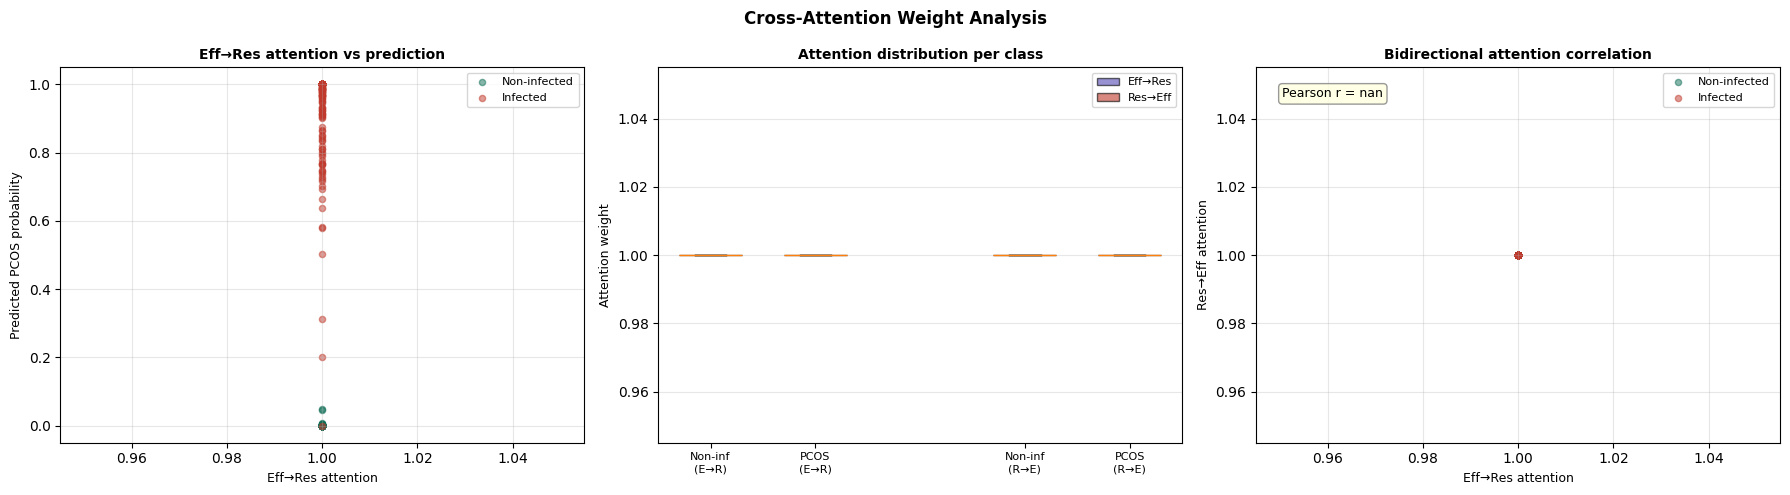

2026-04-03 23:01:56,028 - INFO - Plotting evaluation figure.


Saved → pcos_ablation_outputs/crossattn_attention_analysis.png

[STEP 8] Generating evaluation plots...


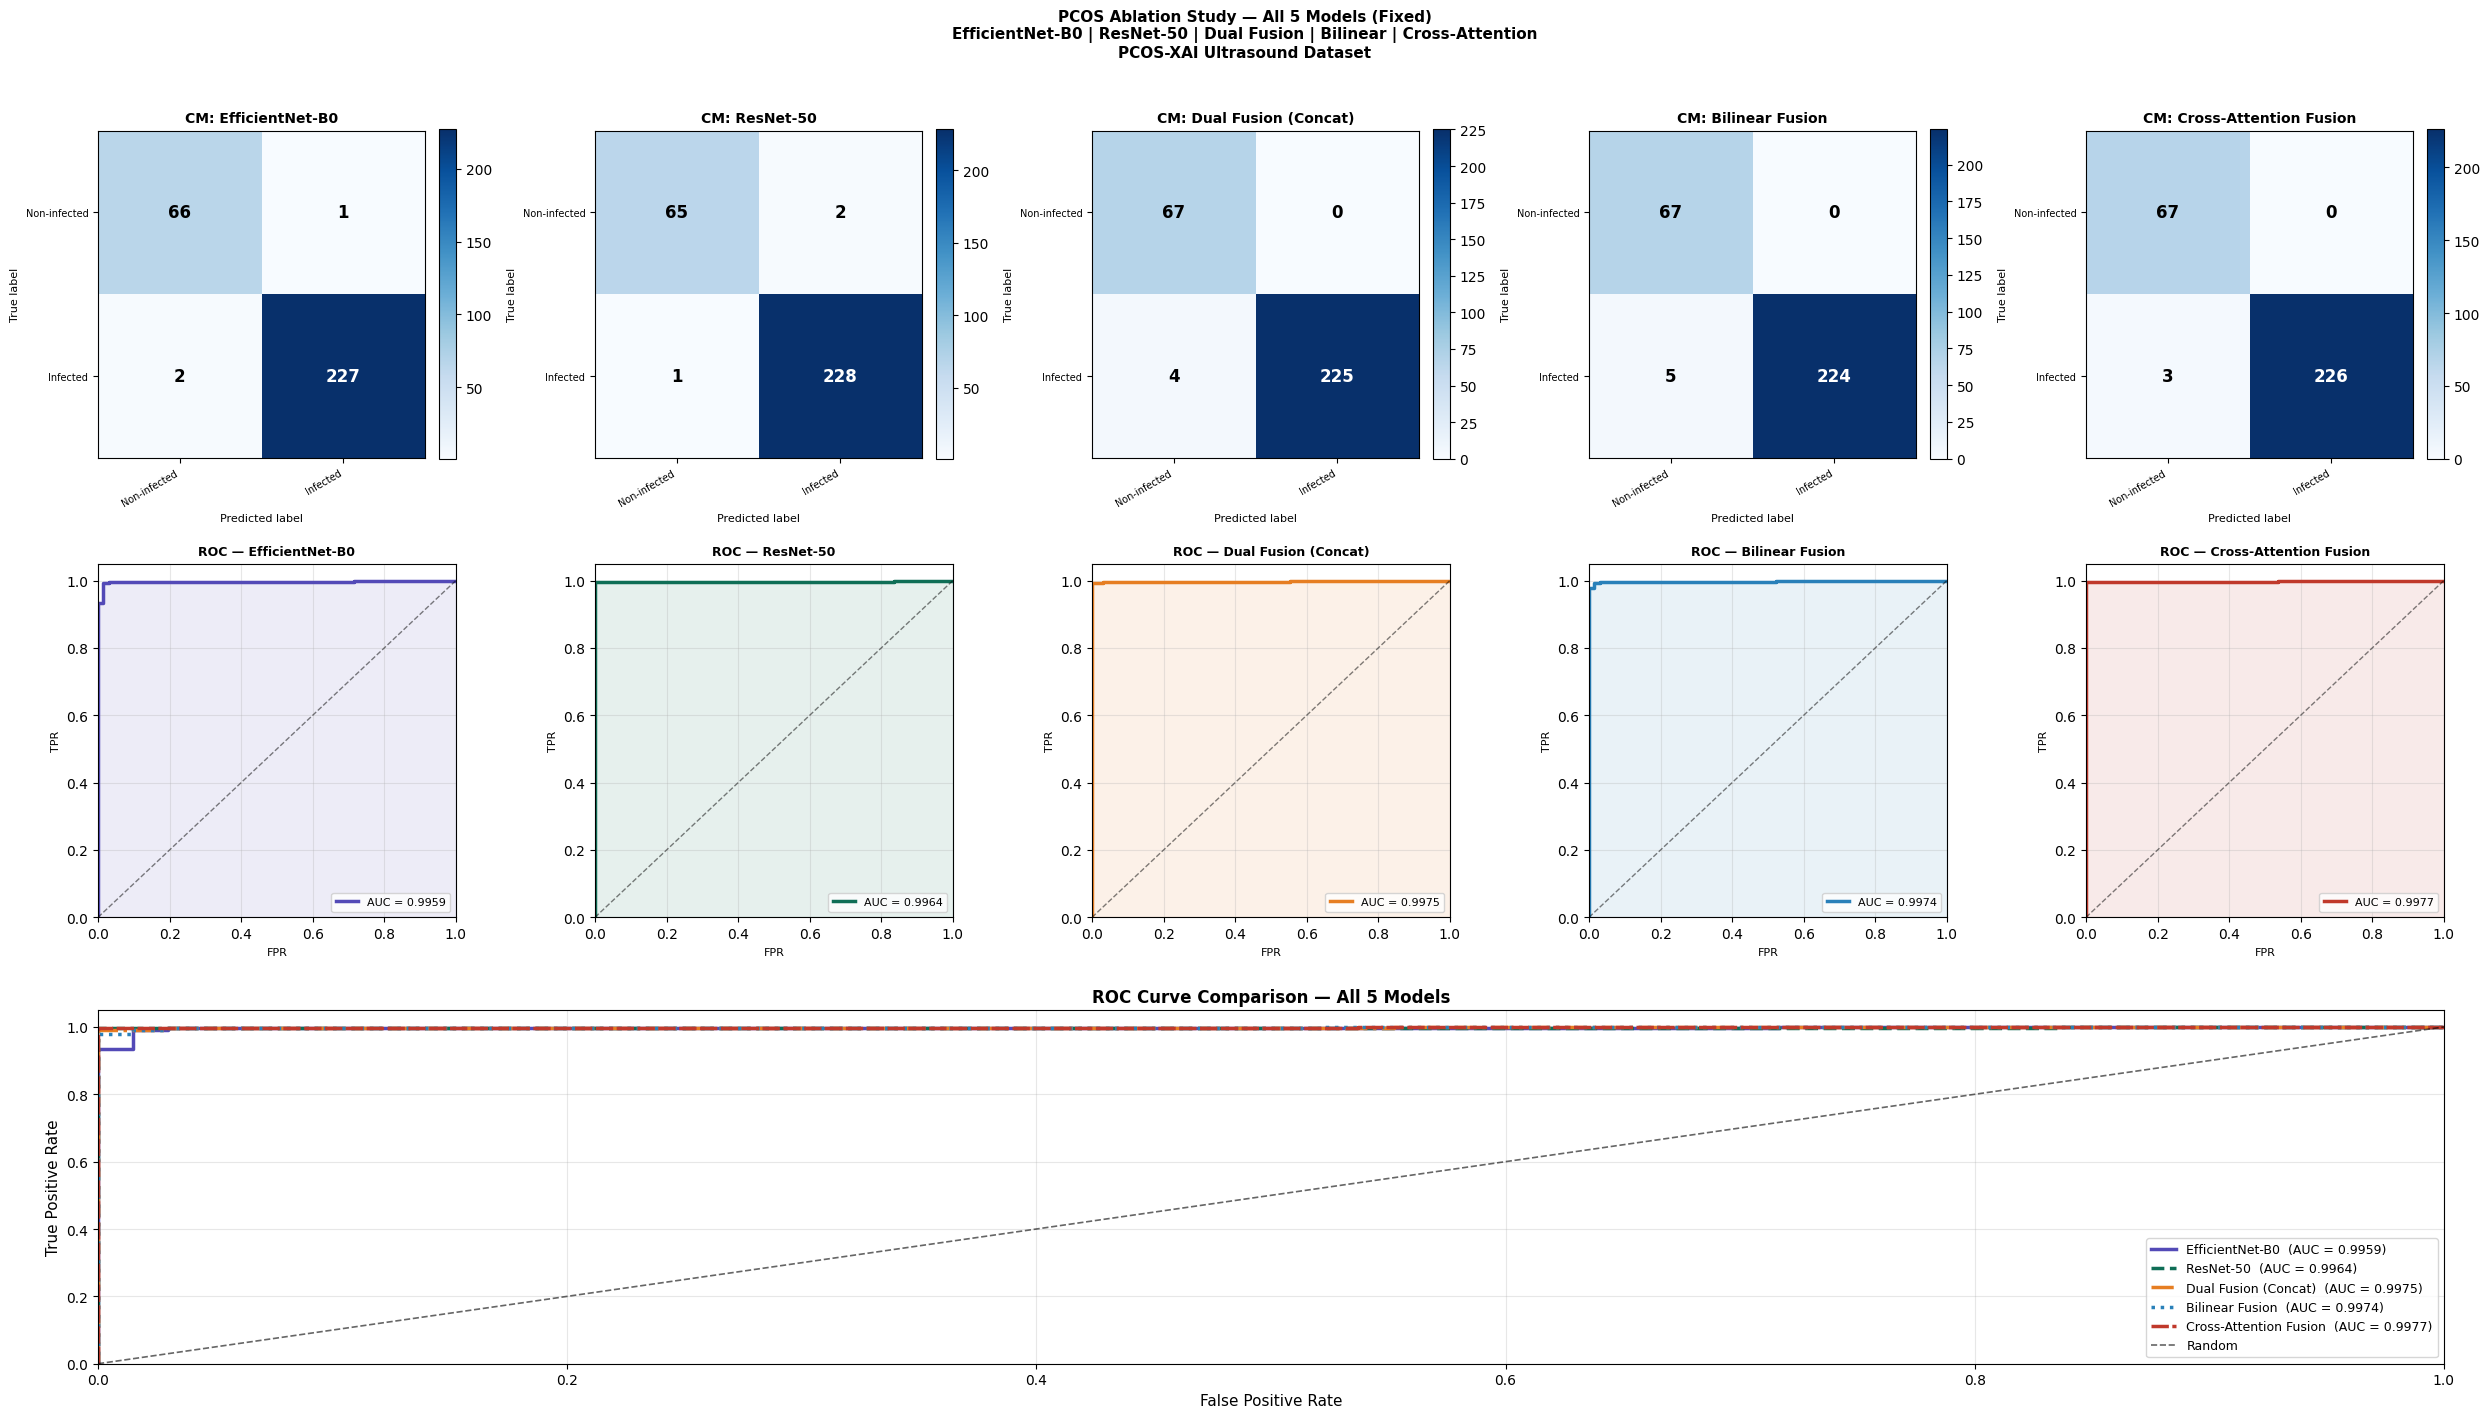

Saved → pcos_ablation_outputs/ablation_evaluation.png


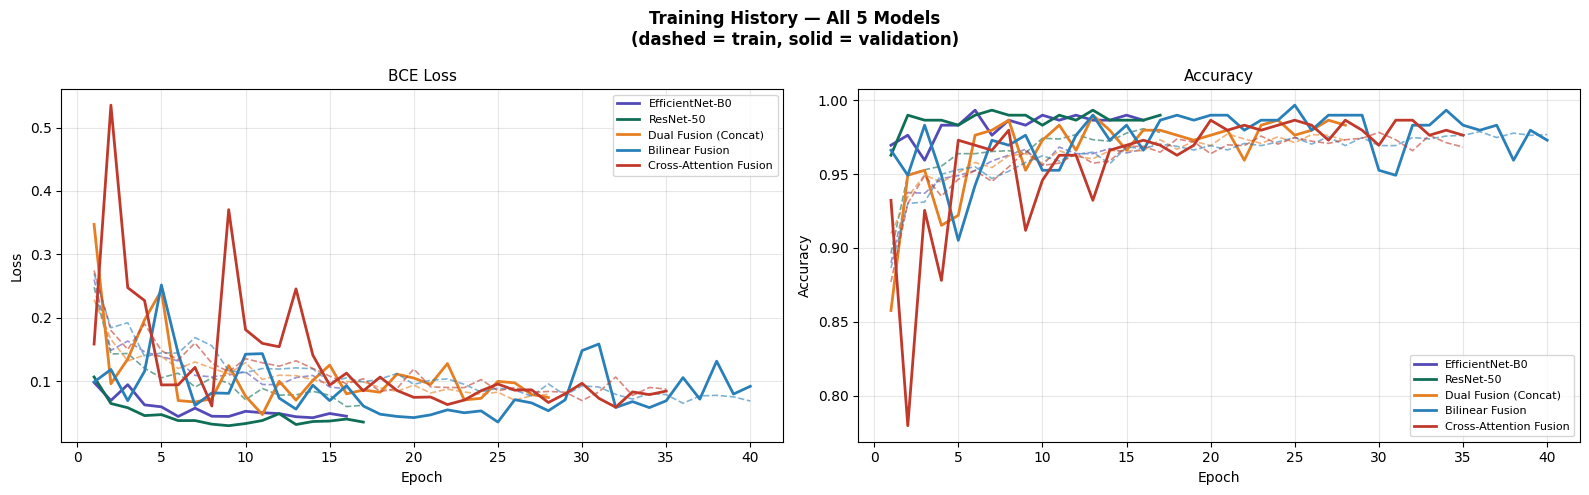

Saved → pcos_ablation_outputs/ablation_training_curves.png


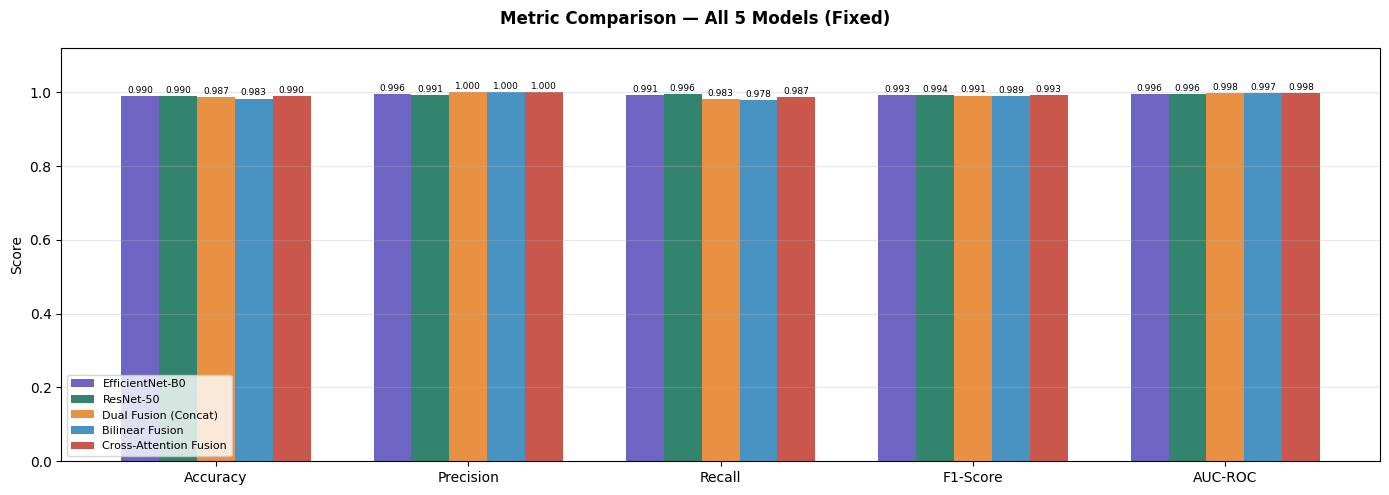

2026-04-03 23:01:57,532 - INFO - === ABLATION STUDY COMPLETE ===


Saved → pcos_ablation_outputs/ablation_metrics_bar.png

  ALL DONE
  Outputs saved in: /Users/tirtha/final year project/3rd/pcos_ablation_outputs/


In [7]:
# ============================================================
#  CELL 7 — RUN EVERYTHING (end-to-end execution)
# ============================================================

log.info('=== PCOS ABLATION STUDY (FIXED) — STARTING ===')
print('=' * 65)
print('  PCOS ABLATION STUDY — ALL 5 MODELS (FIXED)')
print(f'  Device     : {device_label} ({device})')
print(f'  Data dir   : {config.DATA_DIR}')
print(f'  Epochs     : {config.EPOCHS}  |  Batch: {config.BATCH_SIZE}  |  LR: {config.LEARNING_RATE}')
print('=' * 65)

# ── Check dataset path ──────────────────────────────────────
if not os.path.exists(config.DATA_DIR):
    print(f"\n  ERROR: DATA_DIR not found:\n    {config.DATA_DIR}")
    print("  Please update config.DATA_DIR in Cell 2 and re-run.")
    raise SystemExit(1)

# ── STEP 1: Load & deduplicate dataset (shared) ─────────────
print("\n[STEP 1] Loading and deduplicating dataset...")
deduplicator = ImageDeduplicator(
    use_perceptual=config.USE_PERCEPTUAL_HASH,
    hash_size=config.HASH_SIZE,
    similarity_threshold=config.SIMILARITY_THRESHOLD,
)
image_paths, labels = load_dataset(config.DATA_DIR, deduplicator)

# ── STEP 2: Build DataLoaders ────────────────────────────────
# FIX 1: build_dataloaders now returns 6 loaders:
#   [0..2] single-view for baselines, [3..5] dual-view for fusion
print("\n[STEP 2] Building patient-aware DataLoaders...")
(train_loader, val_loader, test_loader,
 train_loader_fusion, val_loader_fusion, test_loader_fusion) = build_dataloaders(image_paths, labels)

print(f'  Baseline  train/val/test batches : {len(train_loader)} / {len(val_loader)} / {len(test_loader)}')
print(f'  Fusion    train/val/test batches : {len(train_loader_fusion)} / {len(val_loader_fusion)} / {len(test_loader_fusion)}')

# ── STEP 3: Initialise all 5 models ─────────────────────────
print("\n[STEP 3] Initialising all 5 models...")
eff_model  = EfficientNetB0Model(dropout_rate=config.DROPOUT_RATE).to(device)
res_model  = ResNet50Model(dropout_rate=config.DROPOUT_RATE).to(device)
dual_model = DualFusionModel(dropout_rate=config.DROPOUT_RATE).to(device)
bili_model = BilinearFusionModel(dropout_rate=config.DROPOUT_RATE,
                                  proj_dim=config.PROJ_DIM).to(device)
ca_model   = CrossAttentionFusionModel(dropout_rate=config.DROPOUT_RATE,
                                        proj_dim=config.PROJ_DIM,
                                        num_heads=config.NUM_HEADS,
                                        attn_dropout=config.ATTN_DROPOUT).to(device)

# ── STEP 4: Train all 5 models ──────────────────────────────
# Baselines use single-view loaders + patience=10
# Fusion models use dual-view loaders + patience=15 (FIX 5)
print("\n[STEP 4] Training all 5 models...")
all_histories = {}

hist, _ = train_model(
    'EfficientNet-B0', eff_model, train_loader, val_loader,
    num_epochs=config.EPOCHS, lr=config.LEARNING_RATE,
    patience=config.EARLY_STOPPING_PATIENCE_BASELINE,
    save_dir=config.SAVE_DIR, is_fusion=False)
all_histories['EfficientNet-B0'] = hist

hist, _ = train_model(
    'ResNet-50', res_model, train_loader, val_loader,
    num_epochs=config.EPOCHS, lr=config.LEARNING_RATE,
    patience=config.EARLY_STOPPING_PATIENCE_BASELINE,
    save_dir=config.SAVE_DIR, is_fusion=False)
all_histories['ResNet-50'] = hist

hist, _ = train_model(
    'Dual Fusion (Concat)', dual_model, train_loader_fusion, val_loader_fusion,
    num_epochs=config.EPOCHS, lr=config.LEARNING_RATE,
    patience=config.EARLY_STOPPING_PATIENCE_FUSION,
    save_dir=config.SAVE_DIR, is_fusion=True)
all_histories['Dual Fusion (Concat)'] = hist

hist, _ = train_model(
    'Bilinear Fusion', bili_model, train_loader_fusion, val_loader_fusion,
    num_epochs=config.EPOCHS, lr=config.LEARNING_RATE,
    patience=config.EARLY_STOPPING_PATIENCE_FUSION,
    save_dir=config.SAVE_DIR, is_fusion=True)
all_histories['Bilinear Fusion'] = hist

hist, _ = train_model(
    'Cross-Attention Fusion', ca_model, train_loader_fusion, val_loader_fusion,
    num_epochs=config.EPOCHS, lr=config.LEARNING_RATE,
    patience=config.EARLY_STOPPING_PATIENCE_FUSION,
    save_dir=config.SAVE_DIR, is_fusion=True)
all_histories['Cross-Attention Fusion'] = hist

# ── STEP 5: Evaluate on test set ────────────────────────────
print("\n[STEP 5] Evaluating all 5 models on the same test set...")
all_results = []

for name, model, loader, is_fusion in [
    ('EfficientNet-B0',        eff_model,  test_loader,        False),
    ('ResNet-50',              res_model,  test_loader,        False),
    ('Dual Fusion (Concat)',   dual_model, test_loader_fusion, True),
    ('Bilinear Fusion',        bili_model, test_loader_fusion, True),
    ('Cross-Attention Fusion', ca_model,   test_loader_fusion, True),
]:
    if is_fusion:
        labels_arr, probs_arr = run_inference_dual(model, loader)
    else:
        labels_arr, probs_arr = run_inference_single(model, loader)
    preds_arr = (probs_arr >= 0.5).astype(int)
    print_classification_report(name, labels_arr, preds_arr)
    all_results.append({
        'name':   name,
        'labels': labels_arr,
        'probs':  probs_arr,
        'preds':  preds_arr,
    })

# ── STEP 6: Summary table ────────────────────────────────────
df_summary = collect_all_metrics(all_results)
print_summary_table(df_summary)
csv_path = os.path.join(config.SAVE_DIR, 'ablation_summary.csv')
df_summary.to_csv(csv_path)
print(f'\nSaved \u2192 {csv_path}')

# ── STEP 7: Cross-attention analysis ─────────────────────────
print("\n[STEP 7] Extracting cross-attention weights (Cross-Attention Fusion)...")
df_attn = visualise_attention_weights(ca_model, test_loader_fusion, config.SAVE_DIR)

# ── STEP 8: Visualisation plots ──────────────────────────────
print("\n[STEP 8] Generating evaluation plots...")
plot_evaluation_figure(all_results, config.SAVE_DIR)
plot_training_curves(all_histories, config.SAVE_DIR)
plot_metric_bar_chart(df_summary, config.SAVE_DIR)

# ── Done ─────────────────────────────────────────────────────
log.info('=== ABLATION STUDY COMPLETE ===')
print("\n" + "=" * 65)
print("  ALL DONE")
print(f"  Outputs saved in: {os.path.abspath(config.SAVE_DIR)}/")
print("=" * 65)